# Exact equivalence analysis

## Goal

The goal of this analysis is to visualize the practical impact of selected SRS rules
on the learning process of the DVPA learner. The reported experiments use exact
equivalence checking. The analysis focuses on the reduction in the
number of equivalence queries and on the total learning time.

## Base-automaton generation

- **Random Automaton:** a randomly generated DVPA with no additional structural
  restrictions. Each transition is generated independently according to the configured
  density. An omitted transition leads to the sink state.
- **Single-Entry Automaton:** a randomly generated automaton whose state set is
  partitioned into pairwise disjoint sets called modules. Local transitions do not
  leave their module. All defined transitions for a given call symbol lead to the
  same state. Thus, calls targeting a given module enter its entry point.

## Target-automaton generation

- **Commutativity:** two random DVPA components are generated over disjoint parts
  of the alphabet and combined into a product automaton. If a return symbol is read
  with a stack symbol belonging to the other component, the transition is undefined
  and therefore leads to the sink state. Operations belonging to different components
  commute.
- **Cancellation:** a random DVPA is extended with a comment construct. Its opening
  symbol enters a comment state and pushes a dedicated stack symbol. The matching
  closing symbol restores the state from which the comment started, yielding the
  cancellation rule.
- **Idempotency:** a single-entry automaton with two additional restrictions:
  1. Every call transition is defined.
  2. A return transition whose stack symbol denotes the current module leaves the
     current state unchanged.

## Used alphabet

The alphabet is fixed for each rule and is not varied during an experiment.
Therefore, changes in the results for a given family are primarily caused by
the increasing size of the target automaton rather than by changes in the alphabet.

The effective alphabets are:

- **Commutativity:** 3 call symbols, 3 local symbols, 3 return symbols, and
  3 stack symbols.
- **Cancellation:** 4 call symbols, 3 local symbols, 4 return symbols, and
  6 stack symbols. One call symbol, one return symbol, and one stack symbol
  are reserved for the cancellable comment construct.
- **Idempotency:** 3 call symbols, 3 local symbols, 3 return symbols, and
  16 stack symbols. The stack alphabet encodes the 5 modules of the
  call-driven automaton and the call symbol that entered a module.

## Methodology

For each target-automaton size and rule, 100 learning runs are performed
with different seeds. Each generated target automaton is learned twice: once without
SRS and once with SRS enabled.

## Reported results

The plots show mean values over all runs for each target-automaton size. They report
the average number of exact equivalence queries and the average learner-run time.


In [5]:
from src import Plot, meanBy

cancellationPath = (
    "data/exactEq/cancellation_increasing_number_of_states.csv"
)
commutativePath = (
    "data/exactEq/commutation_increasing_number_of_states.csv"
)
idempotencyPath = (
    "data/exactEq/idempotency_increasing_number_of_states.csv"
)


def addMeanComparison(plot, csvPath, yColumn, scale=1):
    plot.add(
        csvPath,
        lambda data: meanBy(
            data,
            xColumn="numOfStates",
            yColumn=yColumn,
            filters={"useSrs": 0},
        ) / scale,
        label="Without SRS",
    )
    plot.add(
        csvPath,
        lambda data: meanBy(
            data,
            xColumn="numOfStates",
            yColumn=yColumn,
            filters={"useSrs": 1},
        ) / scale,
        label="With SRS",
    )

## Commutativity

### Average number of equivalence queries

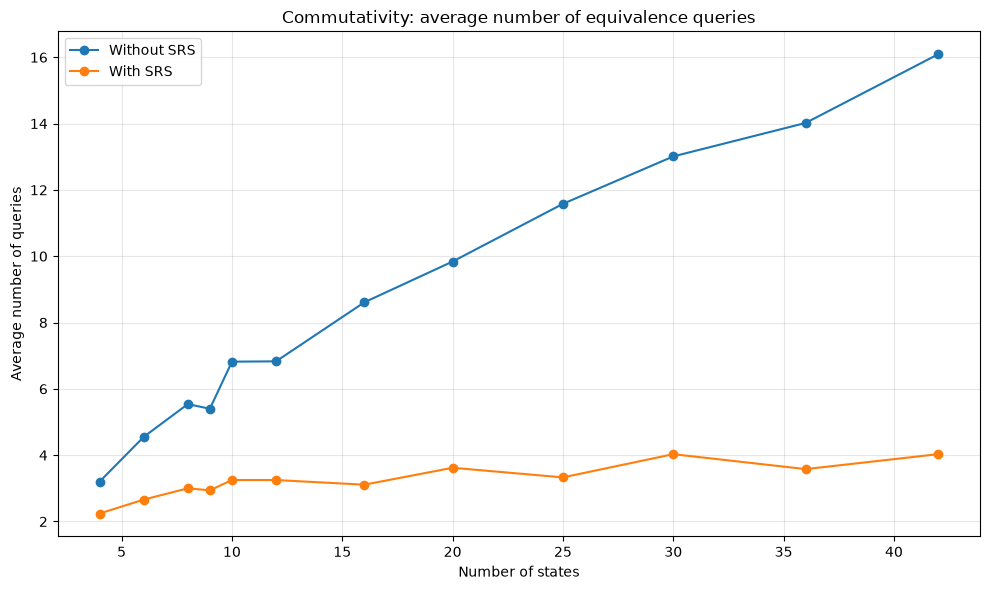

In [6]:
commutativityQueriesPlot = Plot(
    title="Commutativity: average number of equivalence queries",
    xLabel="Number of states",
    yLabel="Average number of queries",
)
addMeanComparison(
    commutativityQueriesPlot,
    commutativePath,
    yColumn="equivalenceQueryCount",
)
commutativityQueriesPlot.draw()

### Average learning time

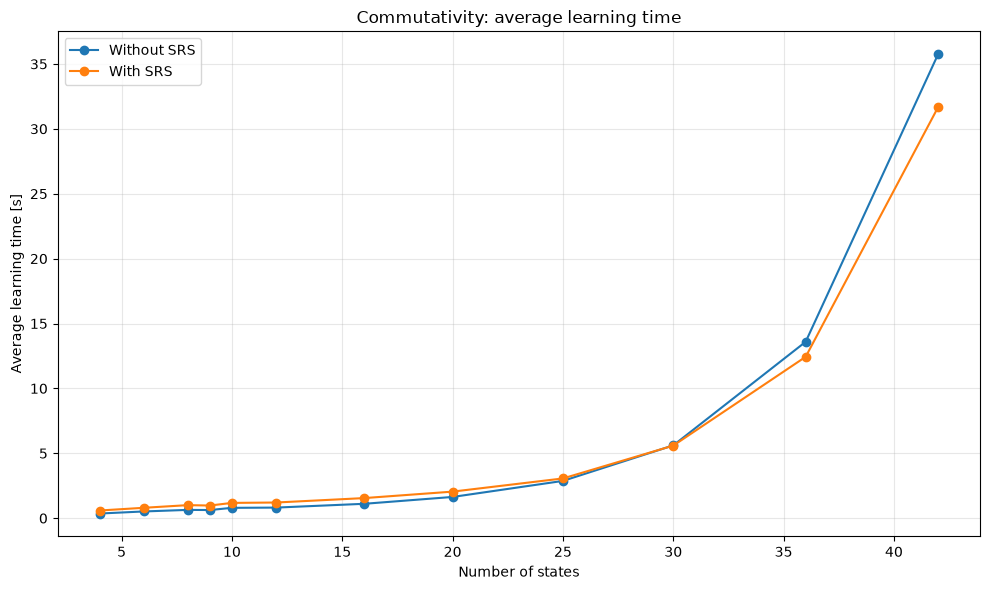

In [7]:
commutativityTimePlot = Plot(
    title="Commutativity: average learning time",
    xLabel="Number of states",
    yLabel="Average learning time [s]",
)
addMeanComparison(
    commutativityTimePlot,
    commutativePath,
    yColumn="learnerTimeUs",
    scale=1_000_000,
)
commutativityTimePlot.draw()

## Cancellation

### Average number of equivalence queries

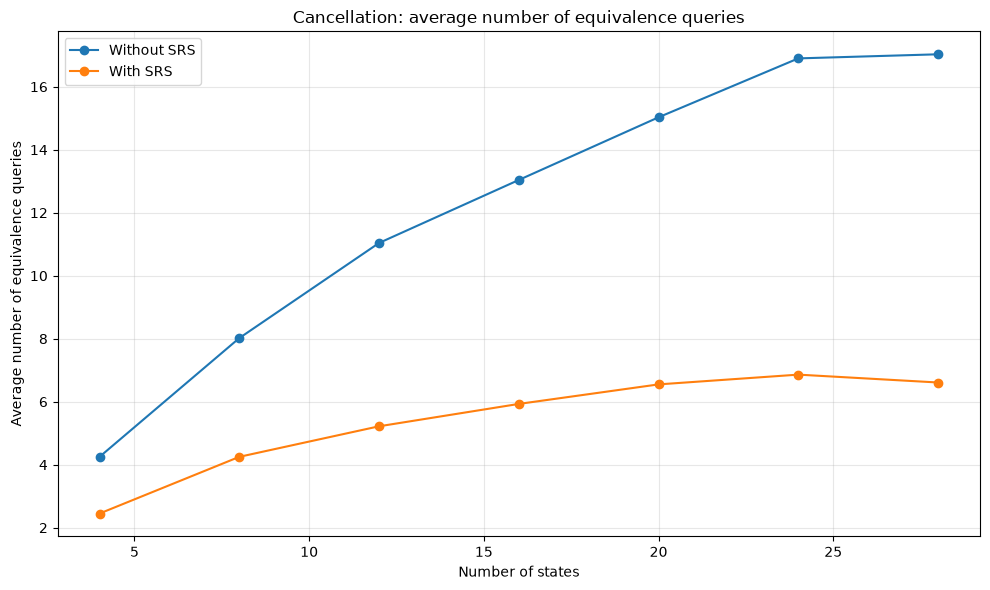

In [12]:
cancellationQueriesPlot = Plot(
    title="Cancellation: average number of equivalence queries",
    xLabel="Number of states",
    yLabel="Average number of equivalence queries",
)
addMeanComparison(
    cancellationQueriesPlot,
    cancellationPath,
    yColumn="equivalenceQueryCount",
)
cancellationQueriesPlot.draw()

### Average learning time

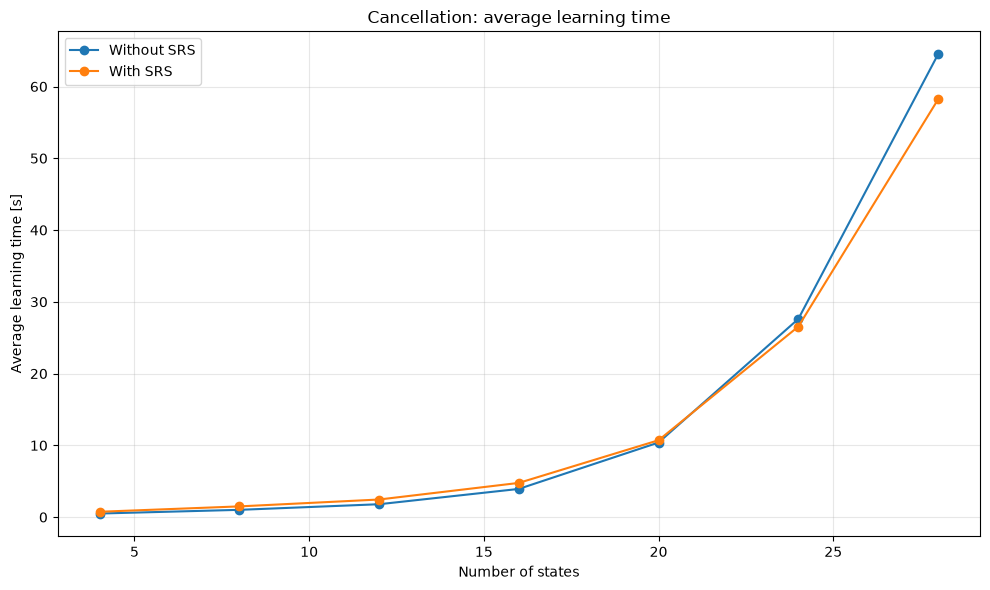

In [8]:
cancellationTimePlot = Plot(
    title="Cancellation: average learning time",
    xLabel="Number of states",
    yLabel="Average learning time [s]",
)
addMeanComparison(
    cancellationTimePlot,
    cancellationPath,
    yColumn="learnerTimeUs",
    scale=1_000_000,
)
cancellationTimePlot.draw()

## Idempotency

### Average number of equivalence queries

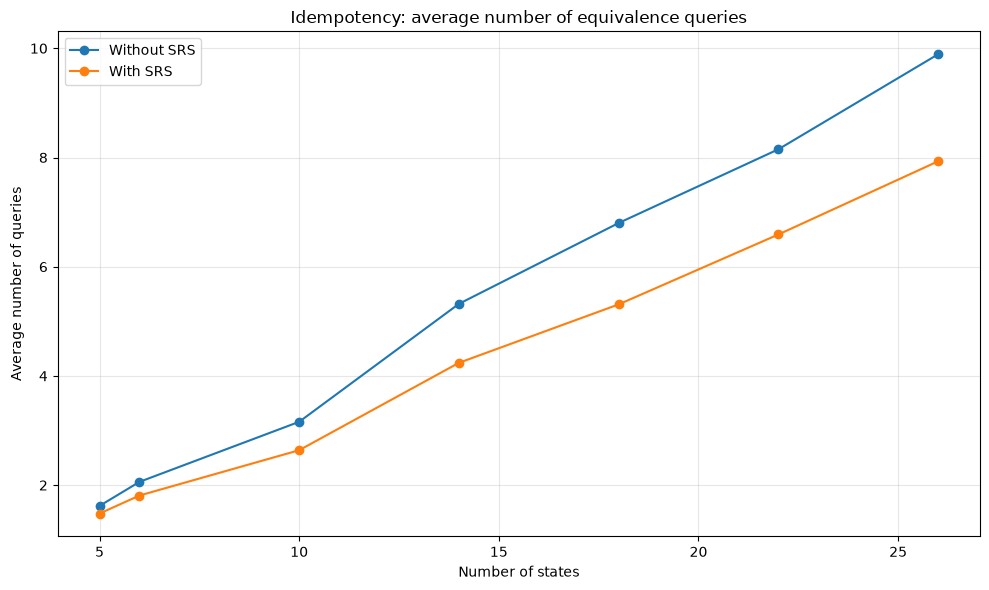

In [9]:
idempotencyQueriesPlot = Plot(
    title="Idempotency: average number of equivalence queries",
    xLabel="Number of states",
    yLabel="Average number of queries",
)
addMeanComparison(
    idempotencyQueriesPlot,
    idempotencyPath,
    yColumn="equivalenceQueryCount",
)
idempotencyQueriesPlot.draw()

### Average learning time

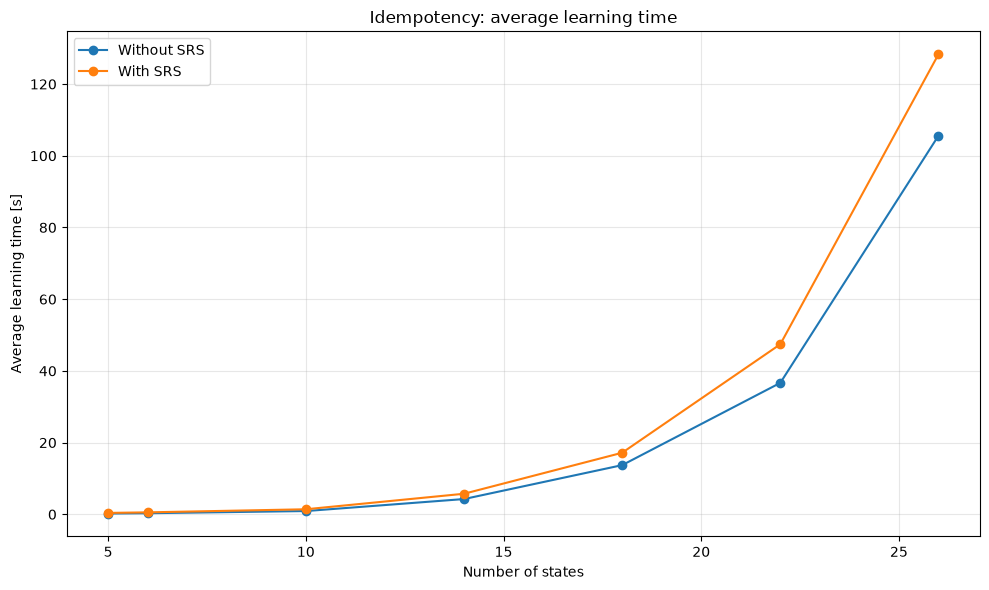

In [10]:
idempotencyTimePlot = Plot(
    title="Idempotency: average learning time",
    xLabel="Number of states",
    yLabel="Average learning time [s]",
)
addMeanComparison(
    idempotencyTimePlot,
    idempotencyPath,
    yColumn="learnerTimeUs",
    scale=1_000_000,
)
idempotencyTimePlot.draw()